# EB1A / E11 Trend Analysis

This notebook analyzes EB1A / E11 trends using the local USCIS dataset. The main question is whether the EB1A denial environment worsened in FY2025 and FY2026, and whether pending cases are likely to resolve into denials at a higher rate than in earlier periods.

Data sources used here:

- `data/analysis_tables/eb1eb2_total_radp.csv`: quarterly RADP-style data for `TOTAL / EB1 / E11 / EB2 / NIW`, FY2022 through FY2026 Q1.
- `data/analysis_tables/i140_yearly_total_eb1_eb2_snapshots.csv`: yearly current-status snapshots for `TOTAL / EB1 / EB2`; historic rows through FY2025 and actual FY2026 Q1.
- `data/exports/i140_status_counts.csv` plus dimension tables: used for EB1 snapshot/proxy pending-conversion analysis.

Important limitation: cohort-level pending conversion is not directly observable for E11 in the current dataset. RADP gives E11 quarterly flows and a pending stock, but it does not track the fate of a specific E11 received cohort. Therefore this notebook separates direct E11 flow analysis from EB1 proxy analysis for pending conversion.


In [1]:
import sys
import subprocess
import importlib.util
from pathlib import Path


def ensure_package(import_name, pip_name=None):
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name or import_name])

ensure_package("matplotlib")
ensure_package("seaborn")
ensure_package("jinja2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

PROJECT_ROOT = Path.cwd()
ANALYSIS_DIR = PROJECT_ROOT / "data" / "analysis_tables"
EXPORT_DIR = PROJECT_ROOT / "data" / "exports"


In [2]:
radp = pd.read_csv(ANALYSIS_DIR / "eb1eb2_total_radp.csv")
yearly = pd.read_csv(ANALYSIS_DIR / "i140_yearly_total_eb1_eb2_snapshots.csv")

facts = pd.read_csv(EXPORT_DIR / "i140_status_counts.csv")
source_files = pd.read_csv(EXPORT_DIR / "source_files.csv")
categories = pd.read_csv(EXPORT_DIR / "preference_categories.csv")
statuses = pd.read_csv(EXPORT_DIR / "case_statuses.csv")
countries = pd.read_csv(EXPORT_DIR / "countries.csv")

radp["period"] = pd.PeriodIndex(radp["fiscal_year"].astype(str) + "Q" + radp["fiscal_quarter"].astype(str), freq="Q-SEP")
radp["period_label"] = radp["fiscal_year"].astype(str) + " Q" + radp["fiscal_quarter"].astype(str)

for df in [radp, yearly]:
    df["decided"] = df["approved"] + df["denied"]
    df["approval_decided"] = np.where(df["decided"] > 0, df["approved"] / df["decided"], np.nan)
    df["denial_decided"] = np.where(df["decided"] > 0, df["denied"] / df["decided"], np.nan)
    df["approval_received"] = np.where(df["received"] > 0, df["approved"] / df["received"], np.nan)
    df["denial_received"] = np.where(df["received"] > 0, df["denied"] / df["received"], np.nan)

e11 = radp[radp["type"] == "E11"].copy()
eb1 = radp[radp["type"] == "EB1"].copy()

print("RADP shape:", radp.shape)
print("Yearly snapshots shape:", yearly.shape)
print("RADP coverage by type:")
display(radp.groupby("type").agg(min_year=("fiscal_year", "min"), max_year=("fiscal_year", "max"), rows=("type", "size")))


RADP shape: (85, 22)
Yearly snapshots shape: (54, 23)
RADP coverage by type:


,min_year,max_year,rows
type,,,
E11,2022,2026,17
EB1,2022,2026,17
EB2,2022,2026,17
NIW,2022,2026,17
TOTAL,2022,2026,17


In [10]:
radp



,fiscal_year,fiscal_quarter,type,type_name,received,approved,denied,pending,approval_rate_received_basis,denial_rate_received_basis,approval_rate_decided_basis,denial_rate_decided_basis,pending_share,source_report_quarter,source_file_names,period,period_label,decided,approval_decided,denial_decided,approval_received,denial_received
0,2022,1,E11,Aliens with Extraordinary Ability,2448,1391,492,5925,0.568219,0.200980,0.738715,0.261285,2.420343,4,I140_FY22_Q4_RADP.csv,2022Q1,2022 Q1,1883,0.738715,0.261285,0.568219,0.200980
1,2022,1,EB1,First Preference,6263,4671,650,19385,0.745809,0.103784,0.877843,0.122157,3.095162,4,I140_FY22_Q4_RADP.csv,2022Q1,2022 Q1,5321,0.877843,0.122157,0.745809,0.103784
2,2022,1,EB2,Second Preference,21624,19903,478,40182,0.920413,0.022105,0.976547,0.023453,1.858213,4,I140_FY22_Q4_RADP.csv,2022Q1,2022 Q1,20381,0.976547,0.023453,0.920413,0.022105
3,2022,1,NIW,National Interest Waiver,4883,3578,252,20584,0.732746,0.051608,0.934204,0.065796,4.215441,4,I140_FY22_Q4_RADP.csv,2022Q1,2022 Q1,3830,0.934204,0.065796,0.732746,0.051608
4,2022,1,TOTAL,Total,42526,38527,1470,101567,0.905963,0.034567,0.963247,0.036753,2.388351,4,I140_FY22_Q4_RADP.csv,2022Q1,2022 Q1,39997,0.963247,0.036753,0.905963,0.034567
5,2022,2,E11,Aliens with Extraordinary Ability,2383,1384,452,6063,0.580781,0.189677,0.753813,0.246187,2.544272,4,I140_FY22_Q4_RADP.csv,2022Q2,2022 Q2,1836,0.753813,0.246187,0.580781,0.189677
6,2022,2,EB1,First Preference,6046,4350,580,20094,0.719484,0.095931,0.882353,0.117647,3.323520,4,I140_FY22_Q4_RADP.csv,2022Q2,2022 Q2,4930,0.882353,0.117647,0.719484,0.095931
7,2022,2,EB2,Second Preference,21764,20057,307,40511,0.921568,0.014106,0.984924,0.015076,1.861377,4,I140_FY22_Q4_RADP.csv,2022Q2,2022 Q2,20364,0.984924,0.015076,0.921568,0.014106
8,2022,2,NIW,National Interest Waiver,4845,3470,161,21045,0.716202,0.033230,0.955660,0.044340,4.343653,4,I140_FY22_Q4_RADP.csv,2022Q2,2022 Q2,3631,0.955660,0.044340,0.716202,0.033230
9,2022,2,TOTAL,Total,40977,36991,1120,97010,0.902726,0.027332,0.970612,0.029388,2.367426,4,I140_FY22_Q4_RADP.csv,2022Q2,2022 Q2,38111,0.970612,0.029388,0.902726,0.027332


## 1. Available EB1A / E11 Data

For E11, the clean quarterly RADP series starts in FY2022 and currently runs through FY2026 Q1.

Fields:

- `received`: E11 petitions received during the quarter.
- `approved`: E11 approvals recorded during the quarter.
- `denied`: E11 denials recorded during the quarter.
- `pending`: pending E11 inventory at the end of the quarter.

`pending` is a stock, not a quarterly flow. It is not limited to petitions received during the same quarter, so `pending / received` can exceed 100% and should not be interpreted as a simple rate.

For true pending-conversion logic, the better source is the yearly current-status snapshot table. However, that table has full status data for `TOTAL / EB1 / EB2`, while E11 is generally available only as an approval subcategory. This is why EB1 is used as the closest proxy for pending conversion.


In [8]:
cols = ["fiscal_year", "fiscal_quarter", "received", "approved", "denied", "pending", "approval_received", "denial_received", "approval_decided", "denial_decided"]
display(e11[cols].style.format({
    "approval_received": "{:.1%}",
    "denial_received": "{:.1%}",
    "approval_decided": "{:.1%}",
    "denial_decided": "{:.1%}",
}))


,fiscal_year,fiscal_quarter,received,approved,denied,pending,approval_received,denial_received,approval_decided,denial_decided
0,2022,1,2448,1391,492,5925,56.8%,20.1%,73.9%,26.1%
5,2022,2,2383,1384,452,6063,58.1%,19.0%,75.4%,24.6%
10,2022,3,2595,1493,433,6137,57.5%,16.7%,77.5%,22.5%
15,2022,4,3055,1355,231,6281,44.4%,7.6%,85.4%,14.6%
20,2023,1,3463,2367,823,6382,68.4%,23.8%,74.2%,25.8%
25,2023,2,3569,2400,1045,6588,67.2%,29.3%,69.7%,30.3%
30,2023,3,4278,2580,1097,7265,60.3%,25.6%,70.2%,29.8%
35,2023,4,4595,3009,1191,7657,65.5%,25.9%,71.6%,28.4%
40,2024,1,4704,2928,1067,8088,62.2%,22.7%,73.3%,26.7%
45,2024,2,5364,3112,1263,8992,58.0%,23.5%,71.1%,28.9%


## 2. E11 Quarterly Dynamics: Received, Approved, Denied, Pending

The first chart shows quarterly flows: `received`, `approved`, and `denied`.

The second chart shows pending backlog separately because pending is measured as an end-of-quarter inventory and has a different scale.


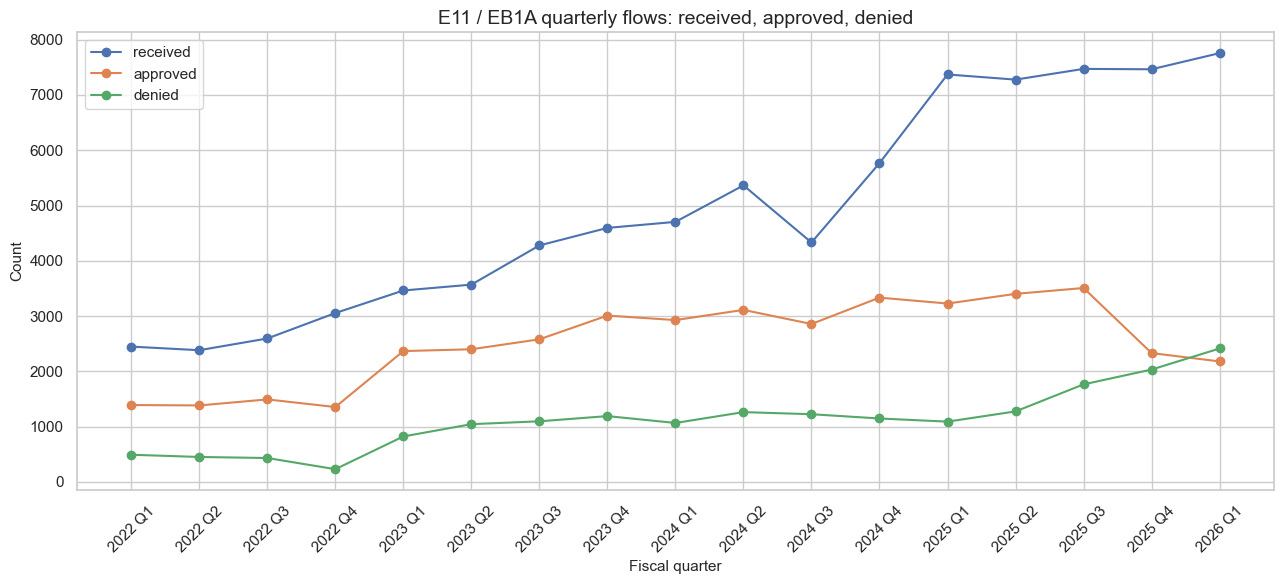

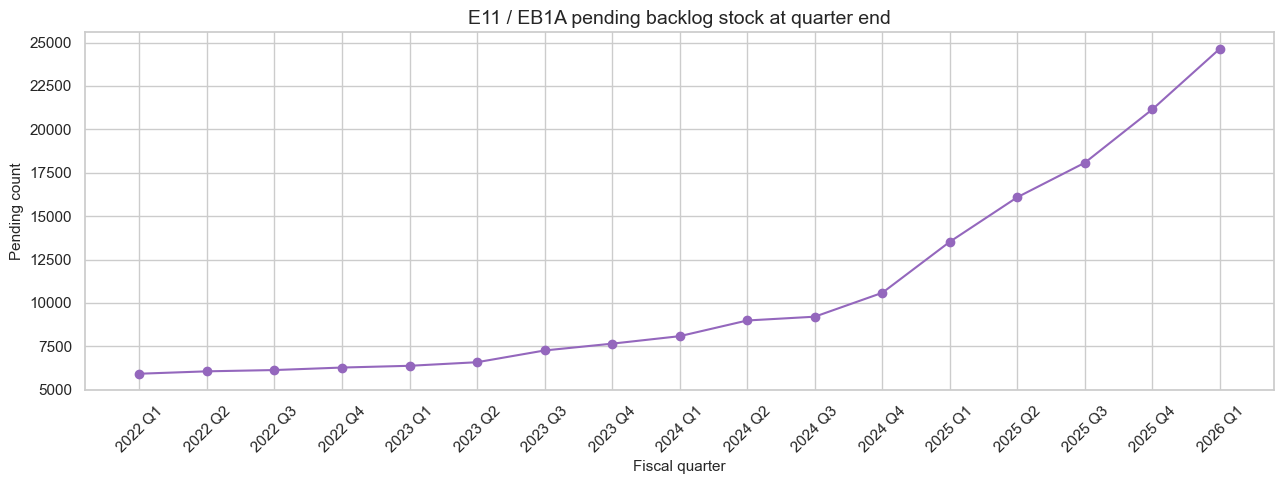

In [4]:
fig, ax = plt.subplots(figsize=(13, 6))
for metric in ["received", "approved", "denied"]:
    ax.plot(e11["period_label"], e11[metric], marker="o", label=metric)
ax.set_title("E11 / EB1A quarterly flows: received, approved, denied")
ax.set_xlabel("Fiscal quarter")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(e11["period_label"], e11["pending"], marker="o", color="tab:purple")
ax.set_title("E11 / EB1A pending backlog stock at quarter end")
ax.set_xlabel("Fiscal quarter")
ax.set_ylabel("Pending count")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## 3. E11 Approval and Denial Rates

Two rate families are useful:

- Received basis: `approved / received` and `denied / received`.
- Decided basis: `approved / (approved + denied)` and `denied / (approved + denied)`.

The decided-basis denial rate is especially useful for detecting adjudication strictness because it looks only at cases that have already received a decision. The received-basis rates are still useful, but they are heavily affected by pending backlog in fresh periods.


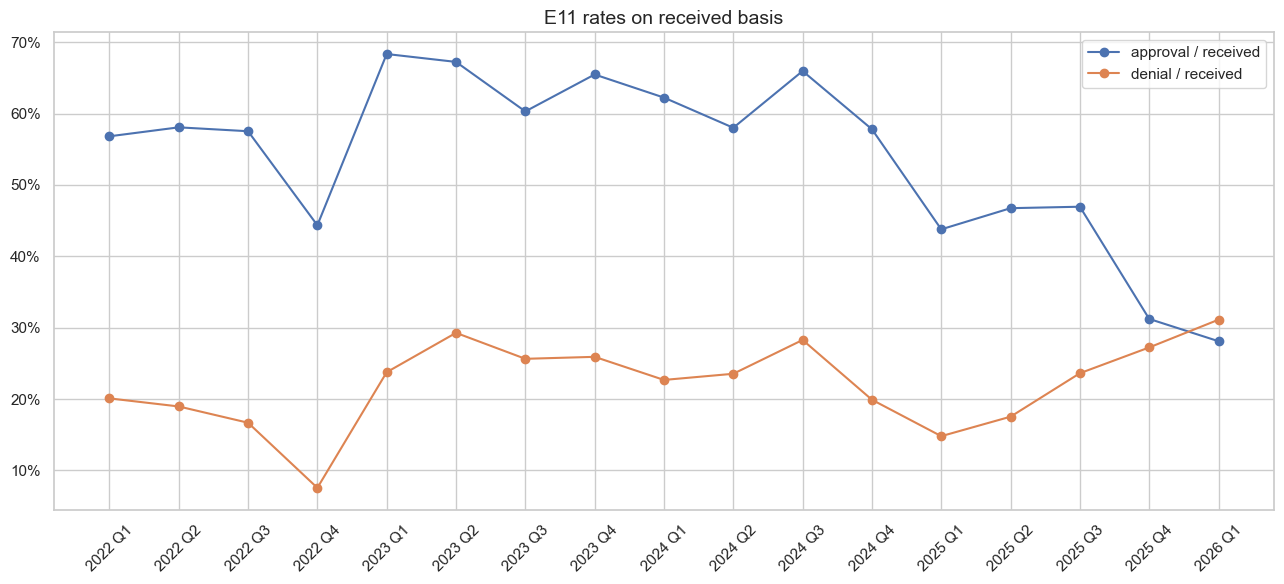

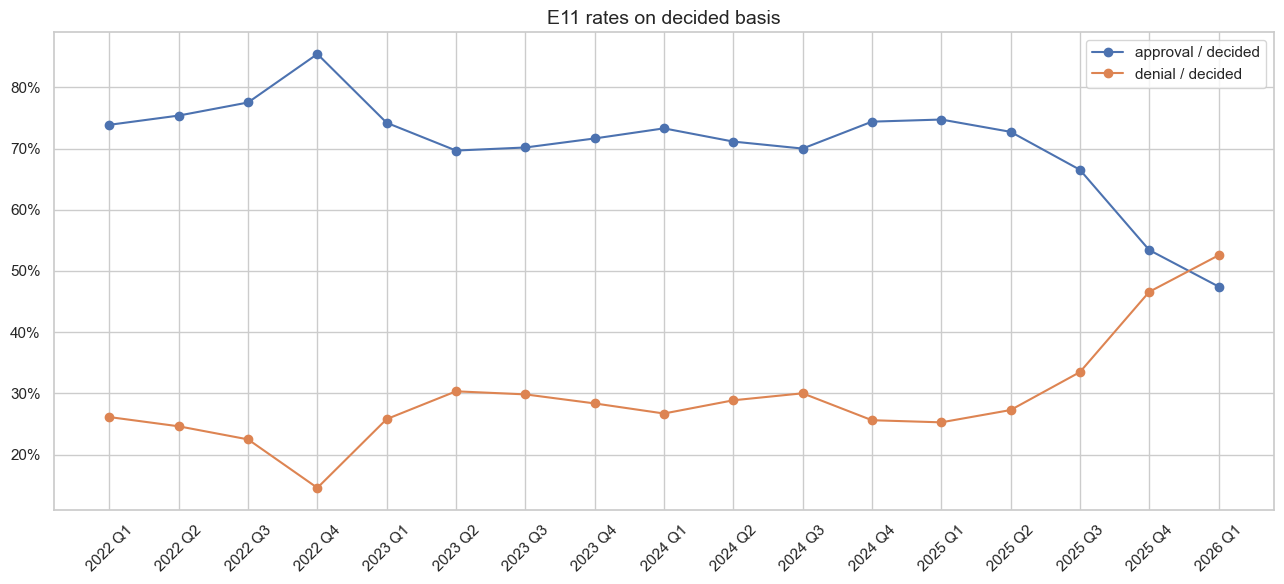

In [5]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(e11["period_label"], e11["approval_received"], marker="o", label="approval / received")
ax.plot(e11["period_label"], e11["denial_received"], marker="o", label="denial / received")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.set_title("E11 rates on received basis")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(e11["period_label"], e11["approval_decided"], marker="o", label="approval / decided")
ax.plot(e11["period_label"], e11["denial_decided"], marker="o", label="denial / decided")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.set_title("E11 rates on decided basis")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()


## 4. Annual E11 Aggregation from RADP

For FY2022 through FY2025, quarterly `received`, `approved`, and `denied` are summed into annual totals. Pending is taken from the last available quarter of each fiscal year.

FY2026 is not a full fiscal year. It currently contains only Q1, so it must be read as an early signal rather than a full-year outcome.


,fiscal_year,received,approved,denied,pending_end,quarters,decided,approval_received,denial_received,approval_decided,denial_decided
0,2022,10481,5623,1608,6281,4,7231,53.6%,15.3%,77.8%,22.2%
1,2023,15905,10356,4156,7657,4,14512,65.1%,26.1%,71.4%,28.6%
2,2024,20166,12231,4703,10586,4,16934,60.7%,23.3%,72.2%,27.8%
3,2025,29582,12468,6165,21157,4,18633,42.1%,20.8%,66.9%,33.1%
4,2026,7756,2180,2414,24653,1,4594,28.1%,31.1%,47.5%,52.5%


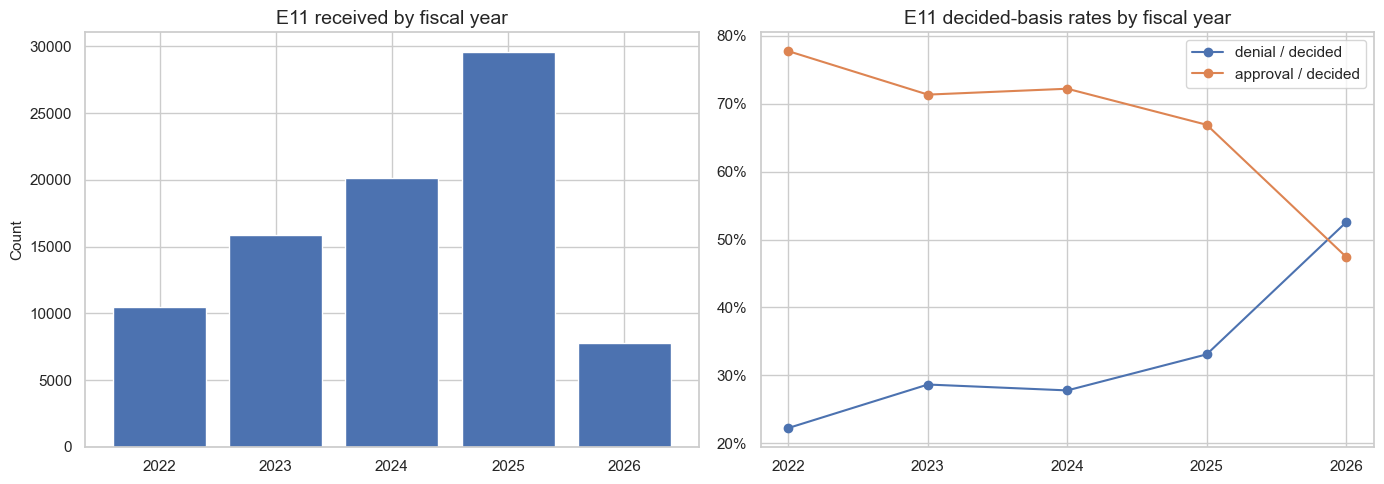

In [6]:
e11_annual = (
    e11.sort_values(["fiscal_year", "fiscal_quarter"])
       .groupby("fiscal_year", as_index=False)
       .agg(
           received=("received", "sum"),
           approved=("approved", "sum"),
           denied=("denied", "sum"),
           pending_end=("pending", "last"),
           quarters=("fiscal_quarter", "nunique"),
       )
)
e11_annual["decided"] = e11_annual["approved"] + e11_annual["denied"]
e11_annual["approval_received"] = e11_annual["approved"] / e11_annual["received"]
e11_annual["denial_received"] = e11_annual["denied"] / e11_annual["received"]
e11_annual["approval_decided"] = e11_annual["approved"] / e11_annual["decided"]
e11_annual["denial_decided"] = e11_annual["denied"] / e11_annual["decided"]

display(e11_annual.style.format({
    "approval_received": "{:.1%}",
    "denial_received": "{:.1%}",
    "approval_decided": "{:.1%}",
    "denial_decided": "{:.1%}",
}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(e11_annual["fiscal_year"].astype(str), e11_annual["received"], label="received")
axes[0].set_title("E11 received by fiscal year")
axes[0].set_ylabel("Count")

axes[1].plot(e11_annual["fiscal_year"].astype(str), e11_annual["denial_decided"], marker="o", label="denial / decided")
axes[1].plot(e11_annual["fiscal_year"].astype(str), e11_annual["approval_decided"], marker="o", label="approval / decided")
axes[1].yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
axes[1].set_title("E11 decided-basis rates by fiscal year")
axes[1].legend()
plt.tight_layout()
plt.show()


## 5. Q1 Comparison: FY2024 vs FY2025 vs FY2026

This is one of the strongest simple tests in the notebook because it compares the same quarter across years.

Hypothesis: if straightforward approvals tend to arrive faster and RFE-heavy or weaker cases take longer, then a sharp decline in Q1 approval share combined with higher pending and/or denial pressure may be an early sign of worsening adjudication conditions.

This test does not prove the RFE mechanism directly, because RFE is not observed in the aggregate dataset. It is an indirect consistency check.


,fiscal_year,received,approved,denied,pending,approval_received,denial_received,approval_decided,denial_decided
0,2022,2448,1391,492,5925,56.8%,20.1%,73.9%,26.1%
20,2023,3463,2367,823,6382,68.4%,23.8%,74.2%,25.8%
40,2024,4704,2928,1067,8088,62.2%,22.7%,73.3%,26.7%
60,2025,7370,3227,1091,13526,43.8%,14.8%,74.7%,25.3%
80,2026,7756,2180,2414,24653,28.1%,31.1%,47.5%,52.5%


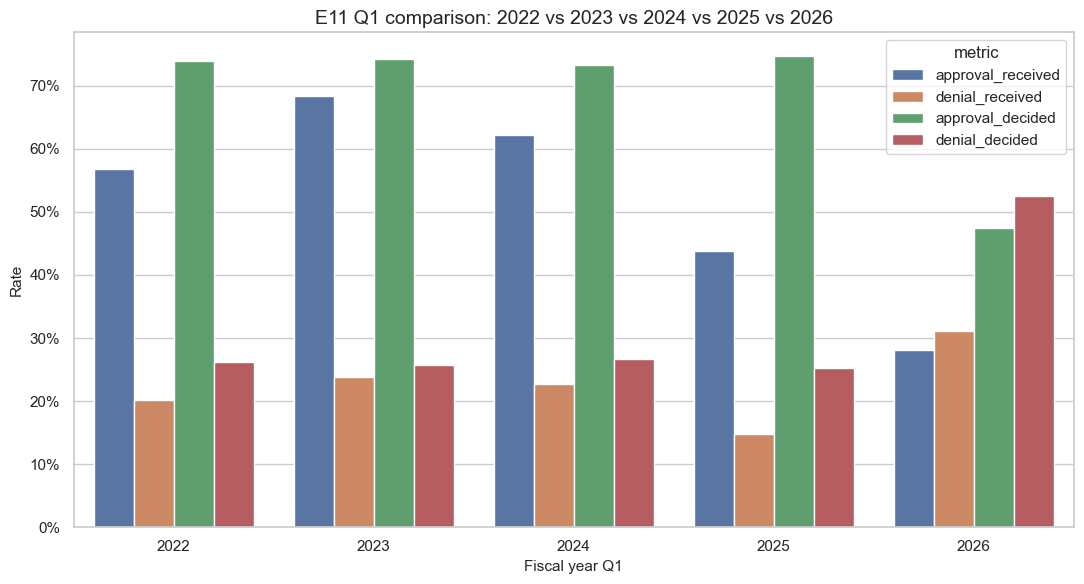

In [12]:
e11_q1 = e11[e11["fiscal_quarter"] == 1].copy()
q1_focus = e11_q1[e11_q1["fiscal_year"].isin([2022, 2023, 2024, 2025, 2026])].copy()

display(q1_focus[["fiscal_year", "received", "approved", "denied", "pending", "approval_received", "denial_received", "approval_decided", "denial_decided"]].style.format({
    "approval_received": "{:.1%}",
    "denial_received": "{:.1%}",
    "approval_decided": "{:.1%}",
    "denial_decided": "{:.1%}",
}))

plot_df = q1_focus.melt(
    id_vars="fiscal_year",
    value_vars=["approval_received", "denial_received", "approval_decided", "denial_decided"],
    var_name="metric",
    value_name="rate",
)
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=plot_df, x="fiscal_year", y="rate", hue="metric", ax=ax)
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.set_title("E11 Q1 comparison: 2022 vs 2023 vs 2024 vs 2025 vs 2026")
ax.set_xlabel("Fiscal year Q1")
ax.set_ylabel("Rate")
plt.tight_layout()
plt.show()


## 6. Pending Conversion: What Can and Cannot Be Measured

Direct E11 pending conversion is not observable with the current files.

Why: RADP pending is an inventory count at the end of the quarter. It does not say which E11 pending petitions from a prior snapshot later became approved or denied.

For a proxy, this notebook uses EB1 yearly current-status snapshots. In those files, the same fiscal-year cohort is updated in later reports: approved, denied, and pending counts change over time. This allows us to estimate how newly resolved pending inventory split between approvals and denials at the EB1 level.

This is a proxy for EB1A, not a direct E11 measurement.


In [13]:
# Build current-status snapshot table from raw facts for TOTAL/EB1/EB2.
sf = source_files.rename(columns={
    "id": "source_file_id",
    "report_fiscal_year": "source_report_fiscal_year",
    "report_quarter": "source_report_quarter",
})
cat = categories.rename(columns={"id": "category_id"})
stat = statuses.rename(columns={"id": "status_id"})
country = countries.rename(columns={"id": "country_id"})

snap = facts.merge(
    sf[["source_file_id", "report_family", "file_name", "source_report_fiscal_year", "source_report_quarter"]],
    on="source_file_id",
)
snap = snap.merge(cat[["category_id", "category_code"]], on="category_id")
snap = snap.merge(stat[["status_id", "status_code"]], on="status_id")
snap = snap.merge(country[["country_id", "country_code"]], on="country_id")
snap = snap[
    (snap["report_family"] == "preference_country")
    & (snap["country_code"] == "ALL")
    & (snap["category_code"].isin(["TOTAL", "EB1", "EB2"]))
].copy()
snap["status_norm"] = snap["status_code"].replace({"pending_other": "pending"})

snap_pivot = snap.pivot_table(
    index=["category_code", "cohort_fiscal_year", "source_report_fiscal_year", "source_report_quarter", "file_name"],
    columns="status_norm",
    values="count_value",
    aggfunc="max",
).reset_index()

snap_pivot = snap_pivot.sort_values(["category_code", "cohort_fiscal_year", "source_report_fiscal_year", "source_report_quarter"])
for col in ["received", "approved", "denied", "pending"]:
    if col not in snap_pivot.columns:
        snap_pivot[col] = np.nan

# Consecutive snapshot deltas for each category/cohort.
transitions = []
for (category, cohort), g in snap_pivot.groupby(["category_code", "cohort_fiscal_year"]):
    g = g.sort_values(["source_report_fiscal_year", "source_report_quarter"]).reset_index(drop=True)
    for i in range(len(g) - 1):
        a = g.iloc[i]
        b = g.iloc[i + 1]
        approved_inc = b["approved"] - a["approved"]
        denied_inc = b["denied"] - a["denied"]
        pending_drop = a["pending"] - b["pending"]
        resolved = approved_inc + denied_inc
        if pd.notna(pending_drop) and pd.notna(resolved) and a["pending"] > 0 and approved_inc >= 0 and denied_inc >= 0:
            transitions.append({
                "category_code": category,
                "cohort_fiscal_year": cohort,
                "from_report": f"{int(a['source_report_fiscal_year'])}Q{int(a['source_report_quarter'])}",
                "to_report": f"{int(b['source_report_fiscal_year'])}Q{int(b['source_report_quarter'])}",
                "pending_start": a["pending"],
                "pending_end": b["pending"],
                "pending_drop": pending_drop,
                "approved_inc": approved_inc,
                "denied_inc": denied_inc,
                "resolved_inc": resolved,
                "denied_share_resolved": denied_inc / resolved if resolved > 0 else np.nan,
                "approved_share_resolved": approved_inc / resolved if resolved > 0 else np.nan,
            })

transitions = pd.DataFrame(transitions)
display(transitions.tail(20).style.format({
    "denied_share_resolved": "{:.1%}",
    "approved_share_resolved": "{:.1%}",
}))


,category_code,cohort_fiscal_year,from_report,to_report,pending_start,pending_end,pending_drop,approved_inc,denied_inc,resolved_inc,denied_share_resolved,approved_share_resolved
165,TOTAL,2022,2023Q2,2023Q2,4969,2623,2346,986,1361,2347,58.0%,42.0%
166,TOTAL,2022,2023Q2,2023Q4,2623,1655,968,355,612,967,63.3%,36.7%
167,TOTAL,2022,2023Q4,2024Q1,1655,815,840,104,736,840,87.6%,12.4%
168,TOTAL,2023,2023Q1,2023Q2,11651,17185,-5534,38650,1317,39967,3.3%,96.7%
169,TOTAL,2023,2023Q2,2023Q2,17185,25379,-8194,40861,3018,43879,6.9%,93.1%
170,TOTAL,2023,2023Q2,2023Q4,25379,41702,-16323,32882,2094,34976,6.0%,94.0%
171,TOTAL,2023,2023Q4,2024Q1,41702,21516,20186,16631,3558,20189,17.6%,82.4%
172,TOTAL,2023,2024Q1,2024Q4,21516,4509,17007,12556,4449,17005,26.2%,73.8%
173,TOTAL,2023,2024Q4,2025Q1,4509,4133,376,99,276,375,73.6%,26.4%
174,TOTAL,2023,2025Q1,2025Q2,4133,3932,201,41,161,202,79.7%,20.3%


## 7. EB1 Proxy: How FY2025 Pending Changed After FY2025 Q4

The most relevant transition currently available is from the FY2025 Q4 report to the FY2026 Q1 report.

For each cohort and category, we calculate:

- `pending_drop = pending_t - pending_t+1`
- `approved_inc = approved_t+1 - approved_t`
- `denied_inc = denied_t+1 - denied_t`
- `denied_share_resolved = denied_inc / (approved_inc + denied_inc)`

This is not perfect accounting because USCIS can revise counts, but it is the closest aggregate signal for how pending inventory is resolving.


,category_code,cohort_fiscal_year,from_report,to_report,pending_start,pending_end,pending_drop,approved_inc,denied_inc,resolved_inc,denied_share_resolved,approved_share_resolved
74,EB1,2024,2025Q4,2026Q1,8101,7615,486,558,158,716,22.1%,77.9%
78,EB1,2025,2025Q4,2026Q1,23266,18222,5044,2617,2455,5072,48.4%,51.6%
122,EB2,2024,2025Q4,2026Q1,23417,21830,1587,772,853,1625,52.5%,47.5%
126,EB2,2025,2025Q4,2026Q1,54571,46473,8098,5444,2647,8091,32.7%,67.3%
180,TOTAL,2024,2025Q4,2026Q1,45393,41765,3628,2789,1128,3917,28.8%,71.2%
184,TOTAL,2025,2025Q4,2026Q1,117277,89984,27293,21902,5418,27320,19.8%,80.2%


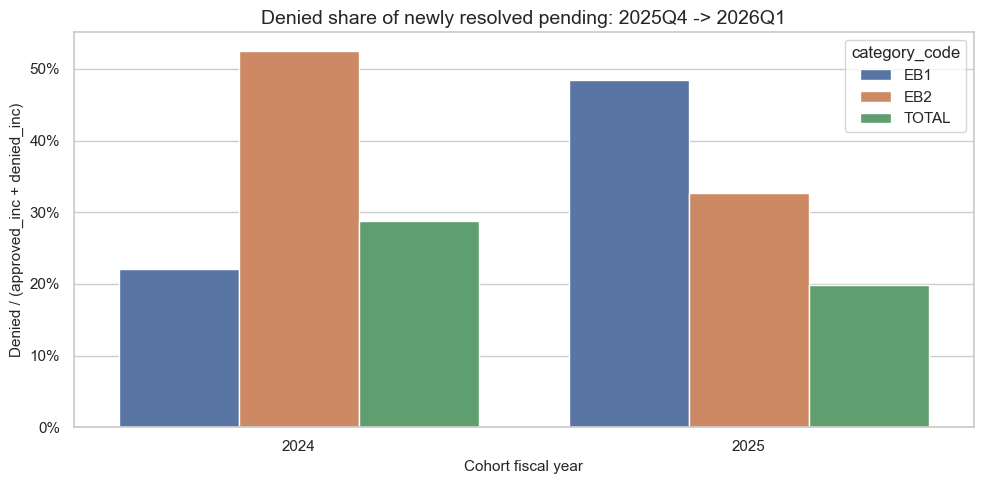

In [14]:
important_transitions = transitions[
    (transitions["category_code"].isin(["EB1", "EB2", "TOTAL"]))
    & (transitions["cohort_fiscal_year"].isin([2024, 2025]))
    & (transitions["from_report"] == "2025Q4")
    & (transitions["to_report"] == "2026Q1")
].copy()

display(important_transitions.style.format({
    "denied_share_resolved": "{:.1%}",
    "approved_share_resolved": "{:.1%}",
}))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=important_transitions, x="cohort_fiscal_year", y="denied_share_resolved", hue="category_code", ax=ax)
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.set_title("Denied share of newly resolved pending: 2025Q4 -> 2026Q1")
ax.set_xlabel("Cohort fiscal year")
ax.set_ylabel("Denied / (approved_inc + denied_inc)")
plt.tight_layout()
plt.show()


## 8. Scenario Forecast Using the EB1 Proxy

A direct E11 final-outcome forecast is not available from the current dataset, so this section builds an EB1 proxy forecast.

The forecast allocates remaining pending inventory into approvals and denials under three scenarios:

- optimistic: 35% of remaining pending resolves as denial;
- base: uses the observed EB1 FY2025 transition from FY2025 Q4 to FY2026 Q1;
- pessimistic: 55% of remaining pending resolves as denial.

This should be read as a directional scenario model, not as a precise prediction. It is useful for stress-testing the hypothesis that recent pending inventory may resolve into denials at an elevated rate.


,target,scenario,observed_received,observed_approved,observed_denied,observed_pending,pending_to_denial,expected_final_approved,expected_final_denied,expected_final_approval_share_of_decided,expected_final_denial_share_of_decided,expected_final_approval_per_received,expected_final_denial_per_received
0,EB1 FY2025 cohort proxy,optimistic,51373,25048,8103,18222,35.0%,36892.300000,14480.700000,71.8%,28.2%,71.8%,28.2%
1,EB1 FY2026 Q1 actual snapshot proxy,optimistic,13040,5961,2562,39463,35.0%,31611.950000,16374.050000,65.9%,34.1%,242.4%,125.6%
2,EB1 FY2025 cohort proxy,base_observed_EB1_2025,51373,25048,8103,18222,48.4%,34450.005915,16922.994085,67.1%,32.9%,67.1%,32.9%
3,EB1 FY2026 Q1 actual snapshot proxy,base_observed_EB1_2025,13040,5961,2562,39463,48.4%,26322.725355,21663.274645,54.9%,45.1%,201.9%,166.1%
4,EB1 FY2025 cohort proxy,pessimistic,51373,25048,8103,18222,55.0%,33247.900000,18125.100000,64.7%,35.3%,64.7%,35.3%
5,EB1 FY2026 Q1 actual snapshot proxy,pessimistic,13040,5961,2562,39463,55.0%,23719.350000,24266.650000,49.4%,50.6%,181.9%,186.1%


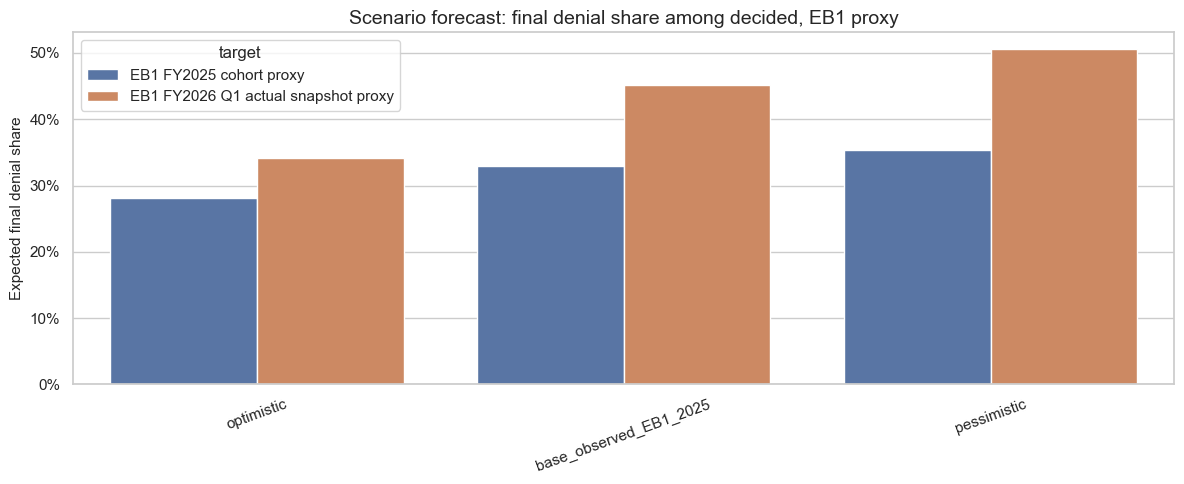

In [15]:
# EB1 latest historic/current-status row for FY2025 after FY2026 Q1 update.
eb1_2025 = yearly[(yearly["type"] == "EB1") & (yearly["fiscal_year"] == 2025) & (yearly["snapshot_type"] == "historic")].iloc[0]
eb1_2026 = yearly[(yearly["type"] == "EB1") & (yearly["fiscal_year"] == 2026) & (yearly["snapshot_type"] == "actual")].iloc[0]

base_denial_share = important_transitions[
    (important_transitions["category_code"] == "EB1")
    & (important_transitions["cohort_fiscal_year"] == 2025)
]["denied_share_resolved"].iloc[0]

scenarios = pd.DataFrame({
    "scenario": ["optimistic", "base_observed_EB1_2025", "pessimistic"],
    "pending_to_denial": [0.35, base_denial_share, 0.55],
})
scenarios["pending_to_approval"] = 1 - scenarios["pending_to_denial"]

forecast_rows = []
for _, row in scenarios.iterrows():
    for label, obs in [("EB1 FY2025 cohort proxy", eb1_2025), ("EB1 FY2026 Q1 actual snapshot proxy", eb1_2026)]:
        expected_denied = obs["denied"] + obs["pending"] * row["pending_to_denial"]
        expected_approved = obs["approved"] + obs["pending"] * row["pending_to_approval"]
        denom = expected_approved + expected_denied
        forecast_rows.append({
            "target": label,
            "scenario": row["scenario"],
            "observed_received": obs["received"],
            "observed_approved": obs["approved"],
            "observed_denied": obs["denied"],
            "observed_pending": obs["pending"],
            "pending_to_denial": row["pending_to_denial"],
            "expected_final_approved": expected_approved,
            "expected_final_denied": expected_denied,
            "expected_final_approval_share_of_decided": expected_approved / denom,
            "expected_final_denial_share_of_decided": expected_denied / denom,
            "expected_final_approval_per_received": expected_approved / obs["received"] if obs["received"] else np.nan,
            "expected_final_denial_per_received": expected_denied / obs["received"] if obs["received"] else np.nan,
        })

forecast = pd.DataFrame(forecast_rows)
display(forecast.style.format({
    "pending_to_denial": "{:.1%}",
    "expected_final_approval_share_of_decided": "{:.1%}",
    "expected_final_denial_share_of_decided": "{:.1%}",
    "expected_final_approval_per_received": "{:.1%}",
    "expected_final_denial_per_received": "{:.1%}",
}))

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=forecast, x="scenario", y="expected_final_denial_share_of_decided", hue="target", ax=ax)
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.set_title("Scenario forecast: final denial share among decided, EB1 proxy")
ax.set_xlabel("")
ax.set_ylabel("Expected final denial share")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


## 9. Findings and Interpretation

### Main findings

1. **E11 denial pressure increased materially.** On a decided basis, annual E11 denial share was approximately 22% in FY2022, 29% in FY2023, 28% in FY2024, 33% in FY2025, and 53% in FY2026 Q1. FY2026 is only one quarter, but the jump is large enough to treat as a serious warning signal.

2. **The Q1 comparison supports the worsening hypothesis.** E11 Q1 approval/received fell from about 62% in FY2024 Q1 to 44% in FY2025 Q1 and 28% in FY2026 Q1. E11 Q1 denial/received rose to about 31% in FY2026 Q1. On a decided basis, FY2026 Q1 has more E11 denials than approvals.

3. **Pending inventory rose sharply.** E11 pending increased from 10,586 at FY2024 Q4 to 21,157 at FY2025 Q4 and 24,653 at FY2026 Q1. This is consistent with delayed adjudication pressure, but the data does not directly identify RFE.

4. **Direct E11 pending conversion cannot be measured from these files.** The dataset does not track E11 pending petitions from one snapshot to their final outcomes. E11 analysis is therefore based on quarterly flows, while pending-conversion analysis uses EB1 as a proxy.

5. **The EB1 proxy is concerning for FY2025.** For the EB1 FY2025 cohort, between the FY2025 Q4 and FY2026 Q1 reports, pending fell by roughly 5,044 while approvals increased by 2,617 and denials increased by 2,455. That implies about 48% of newly resolved EB1 pending became denials in that transition.

6. **The evidence is directionally consistent with the user's hypothesis.** Both direct E11 flow metrics and EB1 pending-resolution proxy metrics point toward a less favorable adjudication environment in FY2025 and especially FY2026 Q1.

### Interpretation for EB1A / E11

The strongest direct EB1A signal is the FY2026 Q1 shift: approvals fell sharply as a share of received petitions, denials rose sharply, and pending remained very high. If the EB1 proxy is directionally relevant to E11, the remaining FY2025/FY2026 pending inventory may resolve with a higher denial share than earlier mature years.

### Important caveats

- FY2026 is only Q1 and should not be annualized mechanically.
- RFE is not observed directly in the USCIS aggregate files.
- EB1 is a proxy for E11, not a substitute for exact E11 cohort tracking.
- USCIS revises historical counts, so transitions can include reporting corrections, not only real adjudication events.
- Pending is an inventory stock, not a same-quarter flow.

### Recommended next steps

- Repeat the same analysis for NIW and compare the pattern with E11.
- Add confidence intervals around quarterly E11 decided-denial rates.
- Backtest the EB1 proxy forecast using older cohorts and earlier snapshots.
- Keep FY2026 visually marked as partial-year / Q1-only in any public chart.
- Update this notebook after each new USCIS quarter and monitor whether FY2025 pending continues to resolve into denials at an elevated rate.
